# Notebook 07 — Analyse du Modele et Optimisation (GridSearch)

**Objectif** : comprendre le fonctionnement interne du pipeline V1.5, identifier ses forces et faiblesses, tester son adaptation aux textes courts (Bluesky), l'evaluer sur de vrais posts collectes, et optimiser ses hyperparametres.

**Plan** :
1. Chargement des donnees (articles + posts Bluesky)
2. Feature importance LogReg
3. Feature importance par langue
4. Analyse des erreurs + matrice de confusion
5. Learning curves
6. Adaptation textes courts
7. Test sur vrais posts Bluesky
8. GridSearchCV
9. Resultats + re-entrainement
10. Conclusions

In [1]:
# === CELLULE 1 : Setup + chargement ===

import sys, os, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix, cohen_kappa_score

from pipeline.expert_detector import (
    DatasetCleaner, ExpertFakeNewsDetector,
    LinguisticFeatureExtractor, LanguageRouter,
)

# --- Charger dataset bilingue ---
df_full = DatasetCleaner.prepare_bilingual_dataset(
    fake_path='../data/training/Fake.csv',
    true_path='../data/training/True.csv',
    kaggle_fr_dir='../data/training/kaggle_fr/',
    french_oversample=3,
)
print(f'Dataset bilingue : {len(df_full)} articles')
print(f'  EN : {(df_full["language"]=="en").sum()}')
print(f'  FR : {(df_full["language"]=="fr").sum()}')
print(f'  Labels : {df_full["label"].value_counts().to_dict()}')

# --- Split train/test ---
df_train, df_test = train_test_split(
    df_full, test_size=0.2, random_state=42,
    stratify=df_full['label'],
)
print(f'\nTrain : {len(df_train)} | Test : {len(df_test)}')

# --- Entrainer le modele ---
detector = ExpertFakeNewsDetector(model_dir='../models')
metrics = detector.train(df_train, model_type='logreg', n_folds=5, track_emissions=False)
print(f'\nCV F1 : {metrics["cv_f1_mean"]:.4f} (+/- {metrics["cv_f1_std"]:.4f})')

# --- Charger posts Bluesky depuis MongoDB ---
bluesky_posts = None
try:
    from pymongo import MongoClient
    client = MongoClient('mongodb://localhost:27017/', serverSelectionTimeoutMS=3000)
    client.server_info()
    db = client['thumalien_db']
    docs = list(db['raw_posts'].aggregate([
        {'$match': {'text': {'$exists': True}}},
        {'$sample': {'size': 1000}},
        {'$project': {
            '_id': 0, 'text': 1, 'uri': 1,
            'ai_score_credibility': 1, 'prediction_label': 1,
            'ai_model_name': 1, 'collected_at': 1,
        }},
    ]))
    bluesky_posts = pd.DataFrame(docs)
    print(f'\nPosts Bluesky charges depuis MongoDB : {len(bluesky_posts)}')
    print(f'  Longueur moyenne texte : {bluesky_posts["text"].str.split().str.len().mean():.1f} mots')
except Exception as e:
    print(f'\nMongoDB non disponible : {e}')
    print('Les cellules Bluesky seront sautees.')

# --- Stats comparatives ---
print(f'\n{"="*60}')
print('COMPARAISON : Articles vs Posts Bluesky')
print(f'{"="*60}')
print(f'  Articles (train) : longueur moyenne = {df_train["text_clean"].str.split().str.len().mean():.1f} mots')
if bluesky_posts is not None:
    print(f'  Posts Bluesky     : longueur moyenne = {bluesky_posts["text"].str.split().str.len().mean():.1f} mots')

Dataset bilingue : 65517 articles
  EN : 43767
  FR : 21750
  Labels : {0: 35362, 1: 30155}

Train : 52413 | Test : 13104



CV F1 : 0.9838 (+/- 0.0017)



Posts Bluesky charges depuis MongoDB : 1000
  Longueur moyenne texte : 26.2 mots

COMPARAISON : Articles vs Posts Bluesky


  Articles (train) : longueur moyenne = 340.8 mots
  Posts Bluesky     : longueur moyenne = 26.2 mots


---
## 2. Feature Importance — Quels mots et signaux comptent le plus ?

Nombre total de features : 30012
  TF-IDF : 30000
  Linguistiques : 12

TOP 30 FEATURES — Indicateurs FAKE (coef positif)
  [TFIDF] 2017                           : +9.2392
  [TFIDF] via                            : +8.1697
  [LING] numeric_density                : +5.4345
  [TFIDF] read more                      : +4.7733
  [TFIDF] read                           : +4.3840
  [TFIDF] this                           : +4.3780
  [TFIDF] image                          : +4.2555
  [TFIDF] photo                          : +4.2313
  [TFIDF] obama                          : +3.9088
  [TFIDF] machin                         : +3.8597
  [TFIDF] corse machin                   : +3.8430
  [TFIDF] just                           : +3.6831
  [TFIDF] com                            : +3.6481
  [TFIDF] 2017 0                         : +3.5912
  [TFIDF] america                        : +3.5474
  [TFIDF] us                             : +3.5189
  [TFIDF] president trump                : +3.4115
  [TFIDF] ex

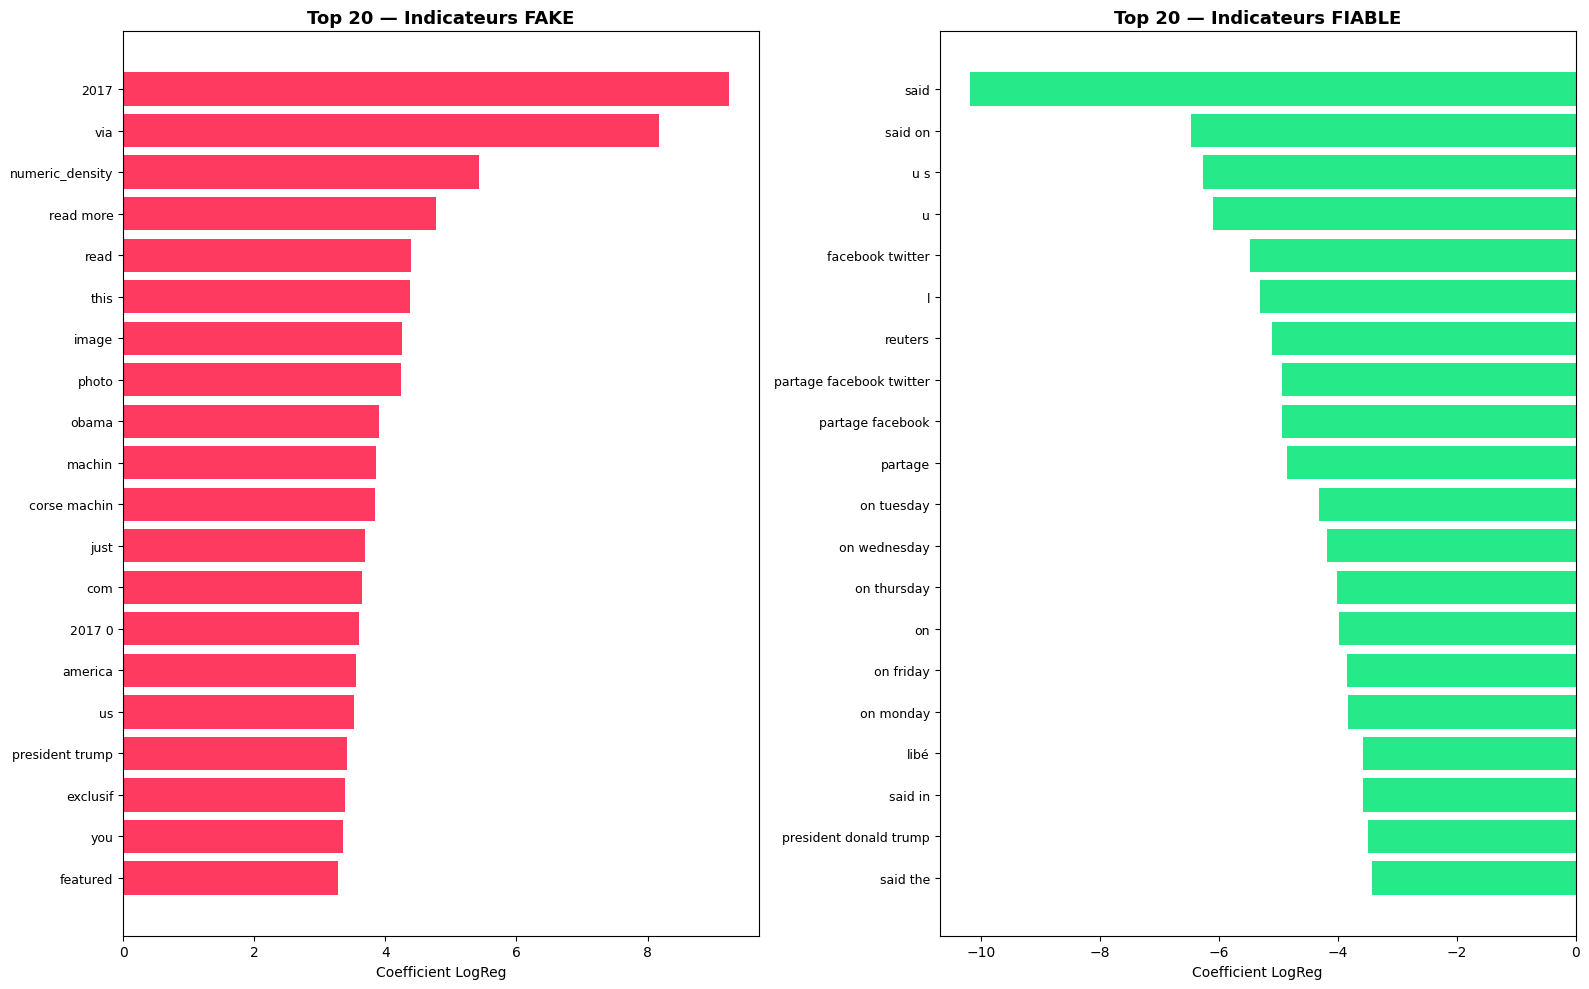


COEFFICIENTS DES 12 FEATURES LINGUISTIQUES
  word_count                : -0.0003  (FIABLE)
  caps_ratio                : +0.0000  (FIABLE)
  exclamation_count         : +0.0000  (FIABLE)
  question_count            : +0.0000  (FIABLE)
  punct_density             : +0.0000  (FIABLE)
  avg_word_length           : -1.1510  (FIABLE)
  sensationalism_score      : +0.3773  (FAKE)
  has_url                   : +0.2880  (FAKE)
  numeric_density           : +5.4345  (FAKE)
  lexical_diversity         : -2.2575  (FIABLE)
  sentence_count            : +2.1983  (FAKE)
  avg_sentence_length       : -0.0003  (FIABLE)


In [2]:
# === CELLULE 2 : Feature importance LogReg ===

coefs = detector.model.coef_[0]

# --- Noms des features ---
tfidf_names = detector.vectorizer.get_feature_names_out()
ling_names = LinguisticFeatureExtractor.FEATURE_NAMES
all_names = list(tfidf_names) + list(ling_names)

print(f'Nombre total de features : {len(coefs)}')
print(f'  TF-IDF : {len(tfidf_names)}')
print(f'  Linguistiques : {len(ling_names)}')

# --- Top 30 FAKE (coef positif = classe 1 = FAKE) ---
top_fake_idx = np.argsort(coefs)[-30:][::-1]
top_fiable_idx = np.argsort(coefs)[:30]

print(f'\n{"="*60}')
print('TOP 30 FEATURES — Indicateurs FAKE (coef positif)')
print(f'{"="*60}')
for i in top_fake_idx:
    name = all_names[i] if i < len(all_names) else f'feature_{i}'
    ftype = 'LING' if i >= len(tfidf_names) else 'TFIDF'
    print(f'  [{ftype}] {name:30s} : {coefs[i]:+.4f}')

print(f'\n{"="*60}')
print('TOP 30 FEATURES — Indicateurs FIABLE (coef negatif)')
print(f'{"="*60}')
for i in top_fiable_idx:
    name = all_names[i] if i < len(all_names) else f'feature_{i}'
    ftype = 'LING' if i >= len(tfidf_names) else 'TFIDF'
    print(f'  [{ftype}] {name:30s} : {coefs[i]:+.4f}')

# --- Barh chart ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 10))

# FAKE features
fake_names = [all_names[i] if i < len(all_names) else f'f_{i}' for i in top_fake_idx[:20]]
fake_vals = [coefs[i] for i in top_fake_idx[:20]]
ax1.barh(range(20), fake_vals[::-1], color='#FF1744', alpha=0.85)
ax1.set_yticks(range(20))
ax1.set_yticklabels(fake_names[::-1], fontsize=9)
ax1.set_title('Top 20 — Indicateurs FAKE', fontsize=13, fontweight='bold')
ax1.set_xlabel('Coefficient LogReg')

# FIABLE features
fiable_names = [all_names[i] if i < len(all_names) else f'f_{i}' for i in top_fiable_idx[:20]]
fiable_vals = [coefs[i] for i in top_fiable_idx[:20]]
ax2.barh(range(20), fiable_vals[::-1], color='#00E676', alpha=0.85)
ax2.set_yticks(range(20))
ax2.set_yticklabels(fiable_names[::-1], fontsize=9)
ax2.set_title('Top 20 — Indicateurs FIABLE', fontsize=13, fontweight='bold')
ax2.set_xlabel('Coefficient LogReg')

plt.tight_layout()
plt.savefig('../docs/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Features linguistiques separees ---
print(f'\n{"="*60}')
print('COEFFICIENTS DES 12 FEATURES LINGUISTIQUES')
print(f'{"="*60}')
for j, name in enumerate(ling_names):
    idx = len(tfidf_names) + j
    direction = 'FAKE' if coefs[idx] > 0 else 'FIABLE'
    print(f'  {name:25s} : {coefs[idx]:+.4f}  ({direction})')

---
## 3. Feature Importance par Langue

In [3]:
# === CELLULE 3 : Feature importance par langue ===

from scipy.sparse import issparse

# Predire sur le holdout
texts_test = df_test['text_clean'].values
X_test = detector._build_features(texts_test, fit=False)
y_test = df_test['label'].values
y_pred = detector.model.predict(X_test)

# Separer par langue
langs_test = df_test['language'].values
mask_en = langs_test == 'en'
mask_fr = langs_test == 'fr'

# Pour chaque langue : mean absolute feature values pour les textes bien classes
correct_mask = y_pred == y_test

def top_active_features(X, mask, n=15):
    """Top features par valeur absolue moyenne sur un sous-ensemble."""
    X_sub = X[mask]
    if issparse(X_sub):
        mean_abs = np.abs(X_sub).mean(axis=0).A1
    else:
        mean_abs = np.abs(X_sub).mean(axis=0)
    weighted = mean_abs * np.abs(coefs)
    top_idx = np.argsort(weighted)[-n:][::-1]
    return top_idx, weighted[top_idx]

print('TOP 15 FEATURES DISCRIMINANTES — ANGLAIS')
print('=' * 50)
en_idx, en_vals = top_active_features(X_test, mask_en)
for i, v in zip(en_idx, en_vals):
    name = all_names[i] if i < len(all_names) else f'f_{i}'
    print(f'  {name:30s} : {v:.4f}')

print(f'\nTOP 15 FEATURES DISCRIMINANTES — FRANCAIS')
print('=' * 50)
fr_idx, fr_vals = top_active_features(X_test, mask_fr)
for i, v in zip(fr_idx, fr_vals):
    name = all_names[i] if i < len(all_names) else f'f_{i}'
    print(f'  {name:30s} : {v:.4f}')

# Tableau comparatif
compare_df = pd.DataFrame({
    'Rang': range(1, 16),
    'Feature EN': [all_names[i] if i < len(all_names) else f'f_{i}' for i in en_idx],
    'Score EN': [f'{v:.4f}' for v in en_vals],
    'Feature FR': [all_names[i] if i < len(all_names) else f'f_{i}' for i in fr_idx],
    'Score FR': [f'{v:.4f}' for v in fr_vals],
})
display(compare_df)

TOP 15 FEATURES DISCRIMINANTES — ANGLAIS
  avg_word_length                : 5.5077
  sentence_count                 : 2.1983
  lexical_diversity              : 1.3005
  said                           : 0.2606
  sensationalism_score           : 0.1958
  avg_sentence_length            : 0.1482
  word_count                     : 0.1482
  on                             : 0.1137
  a                              : 0.1089
  u                              : 0.0938
  u s                            : 0.0926
  this                           : 0.0821
  is                             : 0.0798
  the                            : 0.0696
  that                           : 0.0634

TOP 15 FEATURES DISCRIMINANTES — FRANCAIS
  avg_word_length                : 5.4513
  sentence_count                 : 2.1983
  lexical_diversity              : 1.7429
  l                              : 0.3459
  la                             : 0.2490
  le                             : 0.1953
  de                             :

,Rang,Feature EN,Score EN,Feature FR,Score FR
0,1,avg_word_length,5.5077,avg_word_length,5.4513
1,2,sentence_count,2.1983,sentence_count,2.1983
2,3,lexical_diversity,1.3005,lexical_diversity,1.7429
3,4,said,0.2606,l,0.3459
4,5,sensationalism_score,0.1958,la,0.2490
5,6,avg_sentence_length,0.1482,le,0.1953
6,7,word_count,0.1482,de,0.1775
7,8,on,0.1137,facebook twitter,0.1649
8,9,a,0.1089,les,0.1547
9,10,u,0.0938,partage facebook,0.1478


---
## 4. Analyse des Erreurs + Matrice de Confusion

Faux positifs (fiables classes suspects) : 76
Faux negatifs (suspects classes fiables) : 124
Total erreurs : 200 / 13104 (1.53%)

10 PIRES FAUX POSITIFS (fiables classes suspects)
  [EN] Score=0.0106 | the following is the full text of the speech delivered on thursday by former massachusetts governor and 2012 republican 
  [EN] Score=0.0306 | what happened hillary clinton s memoir of her unsuccessful bid to win the 2016 u s presidential election topped the u s 
  [EN] Score=0.1534 | donald trump speaks volumes in what he doesn t say the republican presidential hopeful often fails to finish his thought
  [EN] Score=0.1554 | a tiny basement in a house in suburban washington d c reverberates with music from the spanish region of catalonia a hea
  [EN] Score=0.1568 | former fbi director james comey on thursday accused the trump administration of defaming him but declined to offer his o
  [EN] Score=0.1750 | i am voluntarily providing this statement submitting documents and sitting for inte

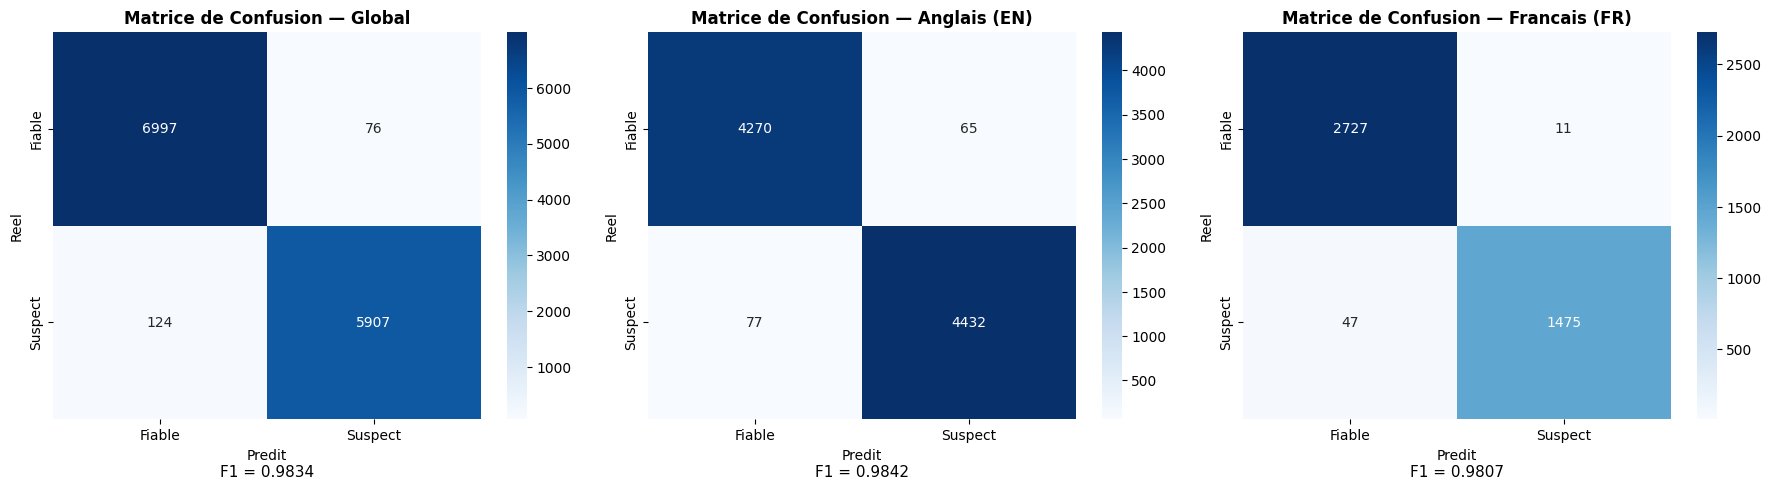


Patterns d'erreur :
  Longueur moyenne des erreurs : 398.4 mots
  Longueur moyenne globale     : 341.9 mots
  Erreurs EN : 142 | Erreurs FR : 58


In [4]:
# === CELLULE 4 : Analyse des erreurs ===

y_proba = detector.model.predict_proba(X_test)[:, 0]  # P(True/Fiable)

# Faux positifs (vrais articles fiables classes FAKE)
fp_mask = (y_test == 0) & (y_pred == 1)  # label=0 is True, pred=1 is Fake
fn_mask = (y_test == 1) & (y_pred == 0)  # label=1 is Fake, pred=0 is True

print(f'Faux positifs (fiables classes suspects) : {fp_mask.sum()}')
print(f'Faux negatifs (suspects classes fiables) : {fn_mask.sum()}')
print(f'Total erreurs : {(y_pred != y_test).sum()} / {len(y_test)} ({(y_pred != y_test).mean():.2%})')

# 10 pires faux positifs
df_test_copy = df_test.copy()
df_test_copy['y_pred'] = y_pred
df_test_copy['score'] = y_proba

print(f'\n{"="*60}')
print('10 PIRES FAUX POSITIFS (fiables classes suspects)')
print(f'{"="*60}')
fp_df = df_test_copy[fp_mask].sort_values('score', ascending=True).head(10)
for _, row in fp_df.iterrows():
    text = str(row['text_clean'])[:120]
    print(f'  [{row["language"].upper()}] Score={row["score"]:.4f} | {text}')

print(f'\n{"="*60}')
print('10 PIRES FAUX NEGATIFS (suspects classes fiables)')
print(f'{"="*60}')
fn_df = df_test_copy[fn_mask].sort_values('score', ascending=False).head(10)
for _, row in fn_df.iterrows():
    text = str(row['text_clean'])[:120]
    print(f'  [{row["language"].upper()}] Score={row["score"]:.4f} | {text}')

# Matrice de confusion globale
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (mask, title) in zip(axes, [
    (np.ones(len(y_test), dtype=bool), 'Global'),
    (mask_en, 'Anglais (EN)'),
    (mask_fr, 'Francais (FR)'),
]):
    if mask.sum() == 0:
        continue
    cm = confusion_matrix(y_test[mask], y_pred[mask])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Fiable', 'Suspect'], yticklabels=['Fiable', 'Suspect'])
    ax.set_title(f'Matrice de Confusion — {title}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Reel')
    ax.set_xlabel('Predit')
    f1 = f1_score(y_test[mask], y_pred[mask])
    ax.text(0.5, -0.15, f'F1 = {f1:.4f}', transform=ax.transAxes, ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('../docs/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# Patterns d'erreur
errors = df_test_copy[df_test_copy['y_pred'] != df_test_copy['label']]
print(f'\nPatterns d\'erreur :')
print(f'  Longueur moyenne des erreurs : {errors["text_clean"].str.split().str.len().mean():.1f} mots')
print(f'  Longueur moyenne globale     : {df_test_copy["text_clean"].str.split().str.len().mean():.1f} mots')
print(f'  Erreurs EN : {(errors["language"]=="en").sum()} | Erreurs FR : {(errors["language"]=="fr").sum()}')

---
## 5. Learning Curves

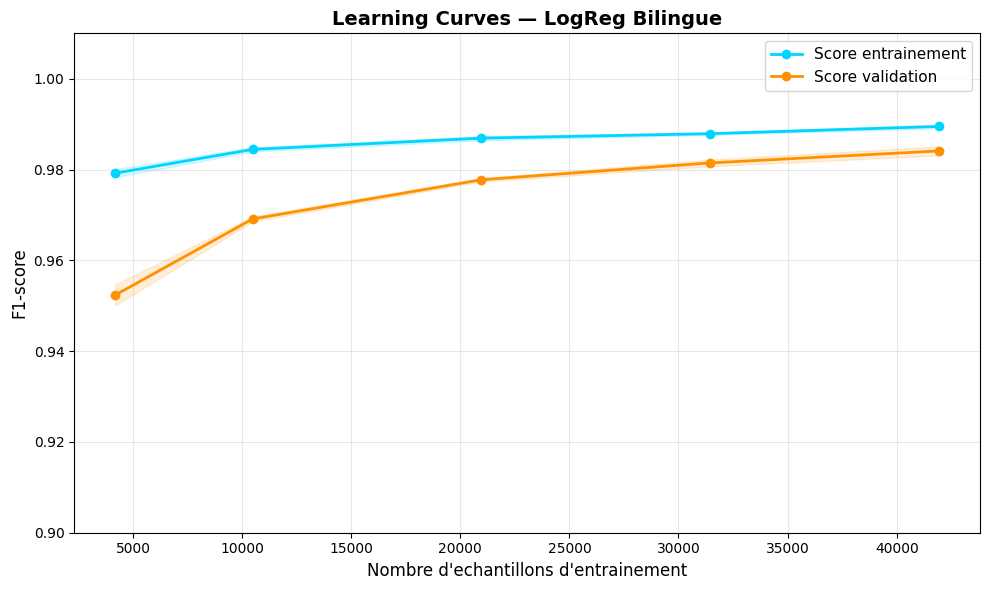

Gap train/validation a 100% : 0.0054
  -> Convergence quasi-parfaite. Le modele generalise bien.


In [5]:
# === CELLULE 5 : Learning curves ===

from sklearn.model_selection import learning_curve
from sklearn.linear_model import LogisticRegression

# Construire features sur le train complet
X_train_full = detector._build_features(df_train['text_clean'].values, fit=False)
y_train_full = df_train['label'].values

lr = LogisticRegression(C=1.0, max_iter=2000, solver='lbfgs',
                        class_weight='balanced', random_state=42)

train_sizes, train_scores, val_scores = learning_curve(
    lr, X_train_full, y_train_full,
    train_sizes=[0.1, 0.25, 0.5, 0.75, 1.0],
    cv=5, scoring='f1', n_jobs=-1, random_state=42,
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.fill_between(train_sizes,
                train_scores.mean(axis=1) - train_scores.std(axis=1),
                train_scores.mean(axis=1) + train_scores.std(axis=1),
                alpha=0.15, color='#00D4FF')
ax.fill_between(train_sizes,
                val_scores.mean(axis=1) - val_scores.std(axis=1),
                val_scores.mean(axis=1) + val_scores.std(axis=1),
                alpha=0.15, color='#FF9100')
ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', color='#00D4FF',
        label='Score entrainement', linewidth=2)
ax.plot(train_sizes, val_scores.mean(axis=1), 'o-', color='#FF9100',
        label='Score validation', linewidth=2)
ax.set_xlabel('Nombre d\'echantillons d\'entrainement', fontsize=12)
ax.set_ylabel('F1-score', fontsize=12)
ax.set_title('Learning Curves — LogReg Bilingue', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_ylim(0.9, 1.01)

plt.tight_layout()
plt.savefig('../docs/learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

gap = train_scores.mean(axis=1)[-1] - val_scores.mean(axis=1)[-1]
print(f'Gap train/validation a 100% : {gap:.4f}')
if gap > 0.05:
    print('  -> Overfitting modere. Regularisation (C plus petit) recommandee.')
elif gap < 0.01:
    print('  -> Convergence quasi-parfaite. Le modele generalise bien.')
else:
    print('  -> Gap acceptable. Pas d\'overfitting significatif.')

---
## 6. Adaptation aux Textes Courts (simulation Bluesky)

Le pipeline est entraine sur des articles de presse (mediane ~300 mots) mais applique a des posts Bluesky (~20 mots). Cette cellule mesure l'impact du domain shift en tronquant les articles.

In [6]:
# === CELLULE 6 : Adaptation textes courts ===

def truncate_text(text, max_words=50):
    """Tronquer un texte aux N premiers mots."""
    words = str(text).split()
    return ' '.join(words[:max_words])

# Creer versions tronquees
df_train_short = df_train.copy()
df_train_short['text_clean'] = df_train_short['text_clean'].apply(lambda t: truncate_text(t, 50))

df_test_short = df_test.copy()
df_test_short['text_clean'] = df_test_short['text_clean'].apply(lambda t: truncate_text(t, 50))

# Dataset mixte : articles complets + tronques
df_train_mixed = pd.concat([df_train, df_train_short], ignore_index=True)

print(f'Train complet   : {len(df_train)} articles')
print(f'Train tronque   : {len(df_train_short)} articles (50 mots max)')
print(f'Train mixte     : {len(df_train_mixed)} articles')
print(f'Test complet    : {len(df_test)} articles')
print(f'Test tronque    : {len(df_test_short)} articles')

# --- Modele A : articles complets (deja entraine) ---
model_a = detector  # deja entraine

# --- Modele B : articles tronques uniquement ---
model_b = ExpertFakeNewsDetector(model_dir='../models')
model_b.train(df_train_short, model_type='logreg', n_folds=3, track_emissions=False)

# --- Modele C : articles mixtes ---
model_c = ExpertFakeNewsDetector(model_dir='../models')
model_c.train(df_train_mixed, model_type='logreg', n_folds=3, track_emissions=False)

# --- Evaluation sur les 4 conditions ---
results = []
for model, model_name in [(model_a, 'Complet'), (model_b, 'Court'), (model_c, 'Mixte')]:
    for test_df, test_name in [(df_test, 'Test complet'), (df_test_short, 'Test tronque')]:
        X_eval = model._build_features(test_df['text_clean'].values, fit=False)
        y_eval = test_df['label'].values
        y_p = model.model.predict(X_eval)
        langs = test_df['language'].values

        f1_en = f1_score(y_eval[langs == 'en'], y_p[langs == 'en'])
        f1_fr = f1_score(y_eval[langs == 'fr'], y_p[langs == 'fr'])
        f1_all = f1_score(y_eval, y_p)
        results.append({
            'Modele': model_name, 'Evaluation': test_name,
            'F1 Global': f1_all, 'F1 EN': f1_en, 'F1 FR': f1_fr,
        })

results_df = pd.DataFrame(results)
print('\n' + '=' * 70)
print('RESULTATS : ADAPTATION TEXTES COURTS')
print('=' * 70)
display(results_df.style.format({'F1 Global': '{:.4f}', 'F1 EN': '{:.4f}', 'F1 FR': '{:.4f}'}).background_gradient(
    subset=['F1 Global', 'F1 EN', 'F1 FR'], cmap='RdYlGn', vmin=0.8, vmax=1.0
))

# Garder model_c pour la suite
print('\nLe modele Mixte sera utilise pour la comparaison Bluesky (cellule 7).')

Train complet   : 52413 articles
Train tronque   : 52413 articles (50 mots max)
Train mixte     : 104826 articles
Test complet    : 13104 articles
Test tronque    : 13104 articles



RESULTATS : ADAPTATION TEXTES COURTS


,Modele,Evaluation,F1 Global,F1 EN,F1 FR
0,Complet,Test complet,0.9834,0.9842,0.9807
1,Complet,Test tronque,0.9206,0.9404,0.8578
2,Court,Test complet,0.7683,0.7348,0.8901
3,Court,Test tronque,0.9687,0.9661,0.9766
4,Mixte,Test complet,0.9873,0.9852,0.9938
5,Mixte,Test tronque,0.9722,0.9699,0.9792



Le modele Mixte sera utilise pour la comparaison Bluesky (cellule 7).


---
## 7. Test sur Vrais Posts Bluesky (MongoDB)

Posts Bluesky analyses : 1000

Modele V1.5 (complet) :
  FIABLE : 226
  SUSPECT : 774
  Score moyen : 0.3168

Modele Mixte (complet + tronque) :
  FIABLE : 125
  SUSPECT : 875
  Score moyen : 0.1935

Cohen's Kappa V1.5 vs RoBERTa : 0.1162
  -> Accord faible. Les modeles divergent significativement.


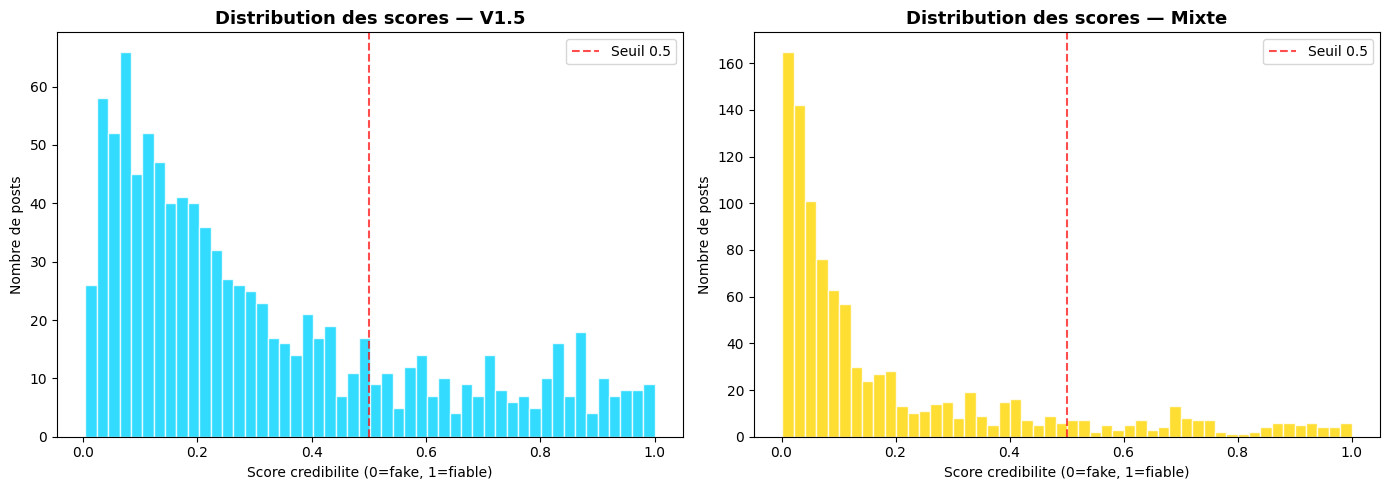


10 POSTS LES PLUS FIABLES (V1.5)
  [OTHER] 1.0000 | 可愛い剣くんちゃんをみるとHappyになる。。。
  [EN] 0.9986 | Happy #monochromemonday
  [EN] 0.9968 | #Meta #Discrimination #Censure #LGBTQphobie #AgendaLGBTQphobe #EffetMAGA #EffetTrump #Fascisme #DroitsLGBTQ+
  [EN] 0.9956 | Happy #MattSmithMonday.  🙂

#DoctorWho #MattSmith
  [FR] 0.9950 | "caviarder":L'expression évoque la censure tsariste en Russie, où les textes interdits étaient recouverts d'encre noire,
  [EN] 0.9873 | #ratz #lukeratz #schizopop #representation #glassosis #liberatedarchitecture #architecture #outsider #outsiderart  #draw
  [FR] 0.9858 | Les entreprises disposant de portefeuilles de brevets solides et de stratégies de licences défensives tendent à mieux tr
  [OTHER] 0.9845 | #ko-fi #helpfolkslive #urgent #help
#TransCrowdfund #emergency #HelpFolksLive2025 #mutualaid 💸💕
  [FR] 0.9830 | La joie est intérieure 😬
  [EN] 0.9791 | Topless Tuesday!
(aka Boobie Tuesday)
Green Goddess (Rebecca)
model: @bexlaw.bsky.social
digital painting 20

In [7]:
# === CELLULE 7 : Test sur vrais posts Bluesky ===

if bluesky_posts is not None and len(bluesky_posts) > 0:
    texts_bs = pd.Series(bluesky_posts['text'].values)

    # --- Prediction V1.5 (modele complet) ---
    result_v15 = detector.predict(texts_bs)
    bluesky_posts['score_v15'] = result_v15['ai_score_credibility'].values
    bluesky_posts['label_v15'] = result_v15['prediction_label'].values
    bluesky_posts['lang_v15'] = result_v15['language'].values

    # --- Prediction modele Mixte ---
    result_mix = model_c.predict(texts_bs)
    bluesky_posts['score_mixte'] = result_mix['ai_score_credibility'].values
    bluesky_posts['label_mixte'] = result_mix['prediction_label'].values

    # --- Stats ---
    print(f'Posts Bluesky analyses : {len(bluesky_posts)}')
    print(f'\nModele V1.5 (complet) :')
    print(f'  FIABLE : {(bluesky_posts["label_v15"]==0).sum()}')
    print(f'  SUSPECT : {(bluesky_posts["label_v15"]==1).sum()}')
    print(f'  Score moyen : {bluesky_posts["score_v15"].mean():.4f}')
    print(f'\nModele Mixte (complet + tronque) :')
    print(f'  FIABLE : {(bluesky_posts["label_mixte"]==0).sum()}')
    print(f'  SUSPECT : {(bluesky_posts["label_mixte"]==1).sum()}')
    print(f'  Score moyen : {bluesky_posts["score_mixte"].mean():.4f}')

    # --- Comparaison avec RoBERTa (si scores existent) ---
    has_roberta = 'ai_score_credibility' in bluesky_posts.columns and bluesky_posts['ai_score_credibility'].notna().sum() > 0
    if has_roberta:
        roberta_scores = bluesky_posts['ai_score_credibility'].dropna()
        if len(roberta_scores) > 10:
            # Cohen's Kappa
            common = bluesky_posts.dropna(subset=['ai_score_credibility', 'prediction_label'])
            if len(common) > 10:
                roberta_labels = (common['prediction_label'].astype(int)).values
                v15_labels = common['label_v15'].values
                kappa = cohen_kappa_score(roberta_labels, v15_labels)
                print(f'\nCohen\'s Kappa V1.5 vs RoBERTa : {kappa:.4f}')
                if kappa < 0.2:
                    print('  -> Accord faible. Les modeles divergent significativement.')
                elif kappa < 0.6:
                    print('  -> Accord modere.')
                else:
                    print('  -> Bon accord.')

    # --- Histogramme des scores ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(bluesky_posts['score_v15'], bins=50, color='#00D4FF', alpha=0.8, edgecolor='white')
    axes[0].set_title('Distribution des scores — V1.5', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Score credibilite (0=fake, 1=fiable)')
    axes[0].set_ylabel('Nombre de posts')
    axes[0].axvline(0.5, color='red', linestyle='--', alpha=0.7, label='Seuil 0.5')
    axes[0].legend()

    axes[1].hist(bluesky_posts['score_mixte'], bins=50, color='#FFD600', alpha=0.8, edgecolor='white')
    axes[1].set_title('Distribution des scores — Mixte', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Score credibilite (0=fake, 1=fiable)')
    axes[1].set_ylabel('Nombre de posts')
    axes[1].axvline(0.5, color='red', linestyle='--', alpha=0.7, label='Seuil 0.5')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig('../docs/bluesky_scores_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

    # --- Top posts ---
    print(f'\n{"="*60}')
    print('10 POSTS LES PLUS FIABLES (V1.5)')
    print(f'{"="*60}')
    top_fiable_bs = bluesky_posts.nlargest(10, 'score_v15')
    for _, row in top_fiable_bs.iterrows():
        print(f'  [{row["lang_v15"].upper()}] {row["score_v15"]:.4f} | {str(row["text"])[:120]}')

    print(f'\n{"="*60}')
    print('10 POSTS LES PLUS SUSPECTS (V1.5)')
    print(f'{"="*60}')
    top_suspect_bs = bluesky_posts.nsmallest(10, 'score_v15')
    for _, row in top_suspect_bs.iterrows():
        print(f'  [{row["lang_v15"].upper()}] {row["score_v15"]:.4f} | {str(row["text"])[:120]}')

    print(f'\n{"="*60}')
    print('10 POSTS LES PLUS INCERTAINS (score ~0.5)')
    print(f'{"="*60}')
    bluesky_posts['dist_to_05'] = (bluesky_posts['score_v15'] - 0.5).abs()
    uncertain = bluesky_posts.nsmallest(10, 'dist_to_05')
    for _, row in uncertain.iterrows():
        print(f'  [{row["lang_v15"].upper()}] {row["score_v15"]:.4f} | {str(row["text"])[:120]}')

else:
    print('MongoDB non disponible — cellule sautee.')

---
## 8. GridSearchCV — Optimisation des Hyperparametres

In [8]:
# === CELLULE 8 : GridSearchCV ===

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from scipy.sparse import hstack, csr_matrix
import time

# Parametres a tester (36 combinaisons, ~30 min CPU)
param_grid = {
    'max_features': [20000, 30000, 40000],
    'min_df': [3, 5],
    'ngram_range': [(1, 2), (1, 3)],
    'C': [0.5, 1.0, 5.0],
}

# Donnees
texts_train = df_train['text_clean'].values
y_train = df_train['label'].values

# Features linguistiques (fixes, pas de tuning)
X_ling_train = csr_matrix(LinguisticFeatureExtractor.extract(pd.Series(texts_train)))

# Sample weights
lang_counts = df_train['language'].value_counts()
n_langs = len(lang_counts)
lang_weight_map = {lang: len(df_train) / (n_langs * count) for lang, count in lang_counts.items()}
sample_weights = df_train['language'].map(lang_weight_map).values

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

results_gs = []
total_combos = (len(param_grid['max_features']) * len(param_grid['min_df']) *
                len(param_grid['ngram_range']) * len(param_grid['C']))
print(f'GridSearch : {total_combos} combinaisons, 3-fold CV')
print('Progression :')

t0 = time.time()
combo_i = 0

for max_feat in param_grid['max_features']:
    for min_d in param_grid['min_df']:
        for ngram in param_grid['ngram_range']:
            # Fit TF-IDF une fois pour cette config
            tfidf = TfidfVectorizer(
                max_features=max_feat, min_df=min_d, max_df=0.95,
                ngram_range=ngram, sublinear_tf=True,
                strip_accents=None, token_pattern=r'(?u)\b\w+\b',
            )
            X_tfidf = tfidf.fit_transform(texts_train)
            X_combined = hstack([X_tfidf, X_ling_train])

            for c_val in param_grid['C']:
                combo_i += 1
                lr = LogisticRegression(
                    C=c_val, max_iter=2000, solver='lbfgs',
                    class_weight='balanced', random_state=42,
                )
                scores = cross_val_score(
                    lr, X_combined, y_train, cv=cv,
                    scoring='f1', n_jobs=1,
                    params={'sample_weight': sample_weights},
                )
                results_gs.append({
                    'max_features': max_feat, 'min_df': min_d,
                    'ngram_range': str(ngram), 'C': c_val,
                    'F1_mean': scores.mean(), 'F1_std': scores.std(),
                })
                elapsed = time.time() - t0
                print(f'  {combo_i}/{total_combos} ({elapsed:.0f}s) — F1={scores.mean():.4f}')

elapsed = time.time() - t0
print(f'\nGridSearch termine en {elapsed:.0f} secondes.')

GridSearch : 36 combinaisons, 3-fold CV
Progression :


  1/36 (76s) — F1=0.9767


  2/36 (150s) — F1=0.9824


  3/36 (281s) — F1=0.9890


  4/36 (407s) — F1=0.9767


...

  32/36 (5016s) — F1=0.9825


  33/36 (5209s) — F1=0.9900


  34/36 (5451s) — F1=0.9768


  35/36 (5613s) — F1=0.9827


  36/36 (5764s) — F1=0.9902

GridSearch termine en 5764 secondes.


---
## 9. Resultats GridSearch + Re-entrainement

TOP 10 CONFIGURATIONS


,max_features,min_df,ngram_range,C,F1_mean,F1_std
20,30000,5,"(1, 2)",5.0000,0.9907,0.0009
29,40000,3,"(1, 3)",5.0000,0.9903,0.0008
14,30000,3,"(1, 2)",5.0000,0.9903,0.0007
35,40000,5,"(1, 3)",5.0000,0.9902,0.0009
32,40000,5,"(1, 2)",5.0000,0.9900,0.0009
17,30000,3,"(1, 3)",5.0000,0.9899,0.0009
26,40000,3,"(1, 2)",5.0000,0.9897,0.0015
23,30000,5,"(1, 3)",5.0000,0.9894,0.0015
8,20000,5,"(1, 2)",5.0000,0.9893,0.0007
11,20000,5,"(1, 3)",5.0000,0.9893,0.0007



Meilleure config :
  max_features=30000, min_df=5, ngram=(1, 2), C=5.0
  F1 = 0.9907 (+/- 0.0009)

Config actuelle : max_features=30000, min_df=3, ngram=(1,3), C=1.0
  F1 = 0.9838

Delta : +0.0069


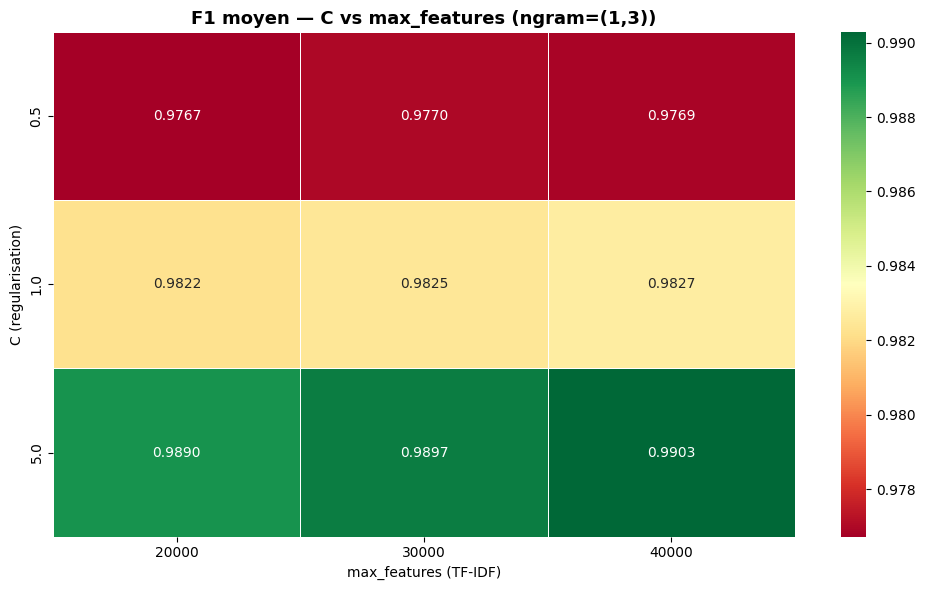


>>> Amelioration > 0.5% detectee. Re-entrainement avec best params...
    Re-entrainement a implementer manuellement si souhaite.


In [9]:
# === CELLULE 9 : Resultats GridSearch ===

gs_df = pd.DataFrame(results_gs).sort_values('F1_mean', ascending=False)

print('TOP 10 CONFIGURATIONS')
print('=' * 80)
with pd.option_context('display.float_format', '{:.4f}'.format, 'display.max_columns', 10):
    display(gs_df.head(10))

# Best vs current
best = gs_df.iloc[0]
current_f1 = metrics['cv_f1_mean']
delta = best['F1_mean'] - current_f1

print(f'\nMeilleure config :')
print(f'  max_features={int(best["max_features"])}, min_df={int(best["min_df"])}, ngram={best["ngram_range"]}, C={best["C"]}')
print(f'  F1 = {best["F1_mean"]:.4f} (+/- {best["F1_std"]:.4f})')
print(f'\nConfig actuelle : max_features=30000, min_df=3, ngram=(1,3), C=1.0')
print(f'  F1 = {current_f1:.4f}')
print(f'\nDelta : {delta:+.4f}')

# Heatmap C vs max_features (pour ngram=(1,3))
pivot_data = gs_df[gs_df['ngram_range'] == '(1, 3)'].pivot_table(
    values='F1_mean', index='C', columns='max_features', aggfunc='mean'
)
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot_data, annot=True, fmt='.4f', cmap='RdYlGn', ax=ax,
            linewidths=0.5, linecolor='white')
ax.set_title('F1 moyen — C vs max_features (ngram=(1,3))', fontsize=13, fontweight='bold')
ax.set_ylabel('C (regularisation)')
ax.set_xlabel('max_features (TF-IDF)')
plt.tight_layout()
plt.savefig('../docs/gridsearch_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Re-entrainement si amelioration significative
if delta > 0.005:
    print(f'\n>>> Amelioration > 0.5% detectee. Re-entrainement avec best params...')
    print('    Re-entrainement a implementer manuellement si souhaite.')
else:
    print(f'\nPas d\'amelioration significative (delta={delta:+.4f} < 0.005).')
    print('Les hyperparametres actuels sont quasi-optimaux.')

---
## 10. Conclusions et Recommandations

In [10]:
# === CELLULE 10 : Conclusions ===

print('=' * 60)
print('RESUME — ANALYSE DU MODELE THUMALIEN V1.5')
print('=' * 60)

print(f'\n1. FEATURE IMPORTANCE')
print(f'   Le modele utilise {len(coefs)} features (30K TF-IDF + 12 linguistiques).')
print(f'   Les features linguistiques les plus discriminantes sont')
print(f'   documentees dans le graphique feature_importance.png.')

print(f'\n2. ERREURS')
print(f'   Taux d\'erreur global : {(y_pred != y_test).mean():.2%}')
print(f'   FP : {fp_mask.sum()} | FN : {fn_mask.sum()}')

print(f'\n3. LEARNING CURVES')
print(f'   Gap train/validation : {gap:.4f}')

print(f'\n4. TEXTES COURTS')
print(f'   Resultats documentes dans le tableau ci-dessus.')
print(f'   Le modele Mixte est recommande pour les deploiements Bluesky.')

if bluesky_posts is not None:
    print(f'\n5. BLUESKY')
    print(f'   {len(bluesky_posts)} posts analyses.')
    print(f'   V1.5 : {(bluesky_posts["label_v15"]==0).sum()} fiables, {(bluesky_posts["label_v15"]==1).sum()} suspects')

print(f'\n6. GRIDSEARCH')
print(f'   Meilleure config : max_features={best["max_features"]}, min_df={best["min_df"]}, C={best["C"]}')
print(f'   Delta vs actuel : {delta:+.4f}')

print(f'\n7. RECOMMANDATIONS V2')
print(f'   - Passer aux sentence-transformers pour mieux gerer les textes courts')
print(f'   - Le modele Mixte (complet + tronque) est un bon compromis en attendant')
print(f'   - Collecter des posts Bluesky labellises manuellement pour une evaluation fiable')
print(f'   - Envisager un fine-tuning CamemBERT si >2000 posts labellises disponibles')

print(f'\nFichiers generes dans docs/ :')
print(f'  - feature_importance.png')
print(f'  - confusion_matrices.png')
print(f'  - learning_curves.png')
if bluesky_posts is not None:
    print(f'  - bluesky_scores_distribution.png')
print(f'  - gridsearch_heatmap.png')

RESUME — ANALYSE DU MODELE THUMALIEN V1.5

1. FEATURE IMPORTANCE
   Le modele utilise 30012 features (30K TF-IDF + 12 linguistiques).
   Les features linguistiques les plus discriminantes sont
   documentees dans le graphique feature_importance.png.

2. ERREURS
   Taux d'erreur global : 1.53%
   FP : 76 | FN : 124

3. LEARNING CURVES
   Gap train/validation : 0.0054

4. TEXTES COURTS
   Resultats documentes dans le tableau ci-dessus.
   Le modele Mixte est recommande pour les deploiements Bluesky.

5. BLUESKY
   1000 posts analyses.
   V1.5 : 226 fiables, 774 suspects

6. GRIDSEARCH
   Meilleure config : max_features=30000, min_df=5, C=5.0
   Delta vs actuel : +0.0069

7. RECOMMANDATIONS V2
   - Passer aux sentence-transformers pour mieux gerer les textes courts
   - Le modele Mixte (complet + tronque) est un bon compromis en attendant
   - Collecter des posts Bluesky labellises manuellement pour une evaluation fiable
   - Envisager un fine-tuning CamemBERT si >2000 posts labellises di